<a href="https://colab.research.google.com/github/kmillaevelyn/data-science-portfolio/blob/main/03-nlp/analise-sentimento-b2w/analise-sentimento-b2w.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#UPLOAD FILE AND LOAD FILE INTO VARIABLE
from google.colab import files
import pandas as pd
import os

# For df_treino
TRAIN_FILENAME_LOCAL = "df_treino.csv"
try:
  df_treino = pd.read_csv(TRAIN_FILENAME_LOCAL)
  print(f"{TRAIN_FILENAME_LOCAL} loaded successfully!")
except FileNotFoundError:
  print("Select the training data (e.g., B2W_10000_70.csv): ")
  uploaded_files = files.upload()
  if uploaded_files:
    # Get the original uploaded filename (key of the dictionary)
    original_uploaded_filename = next(iter(uploaded_files))
    # Write the content to the desired local filename
    with open(TRAIN_FILENAME_LOCAL, "wb") as f:
        f.write(uploaded_files[original_uploaded_filename])
    df_treino = pd.read_csv(TRAIN_FILENAME_LOCAL)
    print(f"Uploaded file '{original_uploaded_filename}' saved and loaded as '{TRAIN_FILENAME_LOCAL}'!")
  else:
    print("No training file uploaded. Please upload the training data.")


# For df_teste
TEST_FILENAME_LOCAL = "df_teste.csv"
try:
  df_teste = pd.read_csv(TEST_FILENAME_LOCAL)
  print(f"{TEST_FILENAME_LOCAL} loaded successfully!")
except FileNotFoundError:
  print("Select the testing data (e.g., B2W_10000_30.csv): ")
  uploaded_files = files.upload()
  if uploaded_files:
    # Get the original uploaded filename (key of the dictionary)
    original_uploaded_filename = next(iter(uploaded_files))
    # Write the content to the desired local filename
    with open(TEST_FILENAME_LOCAL, "wb") as f:
        f.write(uploaded_files[original_uploaded_filename])
    df_teste = pd.read_csv(TEST_FILENAME_LOCAL)
    print(f"Uploaded file '{original_uploaded_filename}' saved and loaded as '{TEST_FILENAME_LOCAL}'!")
  else:
    print("No testing file uploaded. Please upload the testing data.")

df_treino.csv loaded successfully!
df_teste.csv loaded successfully!


In [ ]:
# Criando uma coluna de sentimento:
# Notas 3, 4 e 5 serão consideradas Positivas (1)
# Notas 1 e 2 serão consideradas Negativas (0)
df_treino['sentimento'] = df_treino['overall_rating'].apply(lambda x: 1 if x >= 3 else 0)

print(df_treino[['overall_rating', 'sentimento']].head())

   overall_rating  sentimento
0               5           1
1               1           0
2               4           1
3               1           0
4               5           1


In [ ]:
import pandas as pd

# Preparando a coluna de sentimento na base de teste para comparação
# Notas 3, 4 e 5 serão consideradas Positivas (1)
# Notas 1 e 2 serão consideradas Negativas (0)
df_teste['sentimento_real'] = df_teste['overall_rating'].apply(lambda x: 1 if x >= 3 else 0)

print(f"Total de registros para teste: {len(df_teste)}")

Total de registros para teste: 3000


In [ ]:
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ==========================================
# 1. PRÉ-PROCESSAMENTO DO TEXTO
# ==========================================
def pré_processar_texto(texto):
    # Converte para string e letras minúsculas
    texto = str(texto).lower()
    # Remove pontuações e caracteres especiais, mantendo letras, números e espaços
    texto = re.sub(r'[^\w\s]', '', texto)
    return texto

print("Limpando os textos...")
df_treino['texto_limpo'] = df_treino['review_text'].apply(pré_processar_texto)
df_teste['texto_limpo'] = df_teste['review_text'].apply(pré_processar_texto)

# ==========================================
# 2. VETORIZAÇÃO E MACHINE LEARNING
# ==========================================
print("Treinando o Machine Learning...")
# Vetorizando as palavras (com bigramas)
vectorizer = CountVectorizer(ngram_range=(1, 2))
X_treino = vectorizer.fit_transform(df_treino['texto_limpo'])
y_treino = df_treino['sentimento']

# Ensinando a máquina
modelo_ml = LogisticRegression(max_iter=1000)
modelo_ml.fit(X_treino, y_treino)

# Testando a máquina
X_teste = vectorizer.transform(df_teste['texto_limpo'])
df_teste['predicao_ml'] = modelo_ml.predict(X_teste)

acuracia_ml = accuracy_score(df_teste['sentimento_real'], df_teste['predicao_ml'])
print(f"--- Acurácia do Machine Learning: {acuracia_ml:.2%} ---")

Limpando os textos...
Treinando o Machine Learning...
--- Acurácia do Machine Learning: 89.90% ---


In [ ]:
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score

# ==========================================
# 1. DEFINIÇÃO DO DICIONÁRIO LÉXICO (Expandido)
# ==========================================
dicionario_sentimento = {
    "bom": 1, "ótimo": 2, "excelente": 2, "gostei": 1, "recomendo": 1,
    "ruim": -1, "péssimo": -2, "horrível": -2, "não": -1, "problema": -1,
    "amei": 2, "defeito": -2
}

# Dicionário para rastrear frequências (opcional, usado apenas para treino/análise)
frequencia_palavras_treino = {palavra: 0 for palavra in dicionario_sentimento}

def classificar_lexical(texto, freq_tracker=None):
    pontuacao = 0
    palavras = str(texto).split()
    for palavra in palavras:
        if palavra in dicionario_sentimento:
            pontuacao += dicionario_sentimento[palavra]
            if freq_tracker is not None: # Rastreia a ocorrência se o tracker for fornecido
                freq_tracker[palavra] += 1
    return 1 if pontuacao >= 0 else 0

# ==========================================
# 2. APLICAÇÃO E RESULTADO (NA BASE DE TREINO)
# ==========================================
print("Aplicando o Analisador Léxico na base de TREINO...")
df_treino['predicao_lexical'] = df_treino['texto_limpo'].apply(lambda x: classificar_lexical(x, frequencia_palavras_treino))

acuracia_lexical_treino = accuracy_score(df_treino['sentimento'], df_treino['predicao_lexical'])

# ==========================================
# 3. APLICAÇÃO E RESULTADO (NA BASE DE TESTE)
# ==========================================
print("Aplicando o Analisador Léxico na base de TESTE...")
df_teste['predicao_lexical_lexical'] = df_teste['texto_limpo'].apply(classificar_lexical)

acuracia_lexical_teste = accuracy_score(df_teste['sentimento_real'], df_teste['predicao_lexical_lexical'])

# ==========================================
# 4. GERANDO A TABELA PARA APRESENTAÇÃO
# ==========================================
# Constrói um DataFrame estruturado com as palavras, pesos e ocorrências
df_tabela_lexico = pd.DataFrame(list(dicionario_sentimento.items()), columns=['Palavra', 'Polaridade (Peso)'])
df_tabela_lexico['Ocorrências na Base (Treino)'] = df_tabela_lexico['Palavra'].map(frequencia_palavras_treino)

# Ordena a tabela da palavra mais frequente para a menos frequente
df_tabela_lexico = df_tabela_lexico.sort_values(by='Ocorrências na Base (Treino)', ascending=False).reset_index(drop=True)

print("\n--- TABELA DE PALAVRAS DO DICIONÁRIO LÉXICO ---")
display(df_tabela_lexico)

print(f"\n--- Acurácia do Analisador Léxico (Base de Treino): {acuracia_lexical_treino:.2%} ---")
print(f"--- Acurácia do Analisador Léxico (Base de Teste): {acuracia_lexical_teste:.2%} ---")

Aplicando o Analisador Léxico na base de TREINO...
Aplicando o Analisador Léxico na base de TESTE...

--- TABELA DE PALAVRAS DO DICIONÁRIO LÉXICO ---


,Palavra,Polaridade (Peso),Ocorrências na Base (Treino)
0,não,-1,10800
1,bom,1,2261
2,recomendo,1,1497
3,excelente,2,962
4,problema,-1,849
5,ótimo,2,820
6,gostei,1,646
7,defeito,-2,376
8,ruim,-1,300
9,amei,2,161



--- Acurácia do Analisador Léxico (Base de Treino): 70.00% ---
--- Acurácia do Analisador Léxico (Base de Teste): 72.07% ---


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
from IPython.display import display

# ==========================================
# 1. MATRIZ DE CONFUSÃO (Rodando nos 30% de Teste)
# Mostra onde o modelo acertou e onde se confundiu
# ==========================================
print("--- 1. MATRIZ DE CONFUSÃO (MACHINE LEARNING) ---")
matriz_confusao = pd.crosstab(df_teste['sentimento_real'], df_teste['predicao_ml'],
                              rownames=['Real'], colnames=['Predito pelo ML'], margins=True)
matriz_confusao.rename(index={0: 'Negativo', 1: 'Positivo', 'All': 'Total'},
                       columns={0: 'Negativo', 1: 'Positivo', 'All': 'Total'}, inplace=True)
display(matriz_confusao)


# ==========================================
# 2. RELATÓRIO DE CLASSIFICAÇÃO (Rodando nos 30% de Teste)
# Mostra a precisão do modelo
# ==========================================
print("\n--- 2. RELATÓRIO DE CLASSIFICAÇÃO (MACHINE LEARNING) ---")
relatorio = classification_report(df_teste['sentimento_real'], df_teste['predicao_ml'], output_dict=True)
df_relatorio = pd.DataFrame(relatorio).transpose().round(2)
df_relatorio.rename(index={'0': 'Negativo', '1': 'Positivo', 'accuracy': 'Acurácia Geral',
                           'macro avg': 'Média Macro', 'weighted avg': 'Média Ponderada'}, inplace=True)
display(df_relatorio[['precision', 'recall', 'f1-score', 'support']])


# ==========================================
# 3. AS PALAVRAS MAIS FORTES DO MACHINE LEARNING (Extraídas do Treino)
# Mostra o que a máquina aprendeu
# ==========================================
print("\n--- 3. TOP 10 PALAVRAS POSITIVAS E NEGATIVAS (APRENDIDAS PELO ML) ---")
palavras = vectorizer.get_feature_names_out()
pesos = modelo_ml.coef_[0]

df_pesos = pd.DataFrame({'Palavra/Bigrama': palavras, 'Peso': pesos})

top_positivas = df_pesos.sort_values(by='Peso', ascending=False).head(10).reset_index(drop=True)
top_negativas = df_pesos.sort_values(by='Peso', ascending=True).head(10).reset_index(drop=True)

df_top_palavras = pd.DataFrame({
    'Top 10 Positivas': top_positivas['Palavra/Bigrama'],
    'Peso Positivo': top_positivas['Peso'].round(2),
    'Top 10 Negativas': top_negativas['Palavra/Bigrama'],
    'Peso Negativo': top_negativas['Peso'].round(2)
})
display(df_top_palavras)

--- 1. MATRIZ DE CONFUSÃO (MACHINE LEARNING) ---


Predito pelo ML,Negativo,Positivo,Total
Real,,,
Negativo,587,200,787
Positivo,103,2110,2213
Total,690,2310,3000



--- 2. RELATÓRIO DE CLASSIFICAÇÃO (MACHINE LEARNING) ---


,precision,recall,f1-score,support
Negativo,0.85,0.75,0.79,787.0
Positivo,0.91,0.95,0.93,2213.0
Acurácia Geral,0.90,0.90,0.90,0.9
Média Macro,0.88,0.85,0.86,3000.0
Média Ponderada,0.90,0.90,0.90,3000.0



--- 3. TOP 10 PALAVRAS POSITIVAS E NEGATIVAS (APRENDIDAS PELO ML) ---


,Top 10 Positivas,Peso Positivo,Top 10 Negativas,Peso Negativo
0,excelente,1.36,não recomendo,-1.16
1,ótimo,1.11,pior,-0.89
2,muito bom,0.85,começou,-0.76
3,ótima,0.82,dinheiro,-0.70
4,bom,0.70,não,-0.68
5,gostei,0.68,não afina,-0.65
6,parabéns,0.67,afina,-0.65
7,recomendo,0.61,som quase,-0.65
8,obrigada,0.57,bom som,-0.63
9,que não,0.55,ruim,-0.63


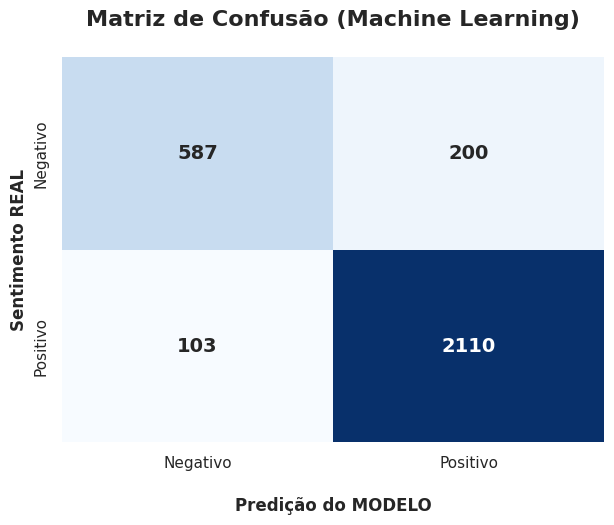

/tmp/ipykernel_2417/1832452279.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Palavra', data=top_pos, ax=axes[0], palette='Greens_r')
/tmp/ipykernel_2417/1832452279.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Palavra', data=top_neg, ax=axes[1], palette='Reds_r')


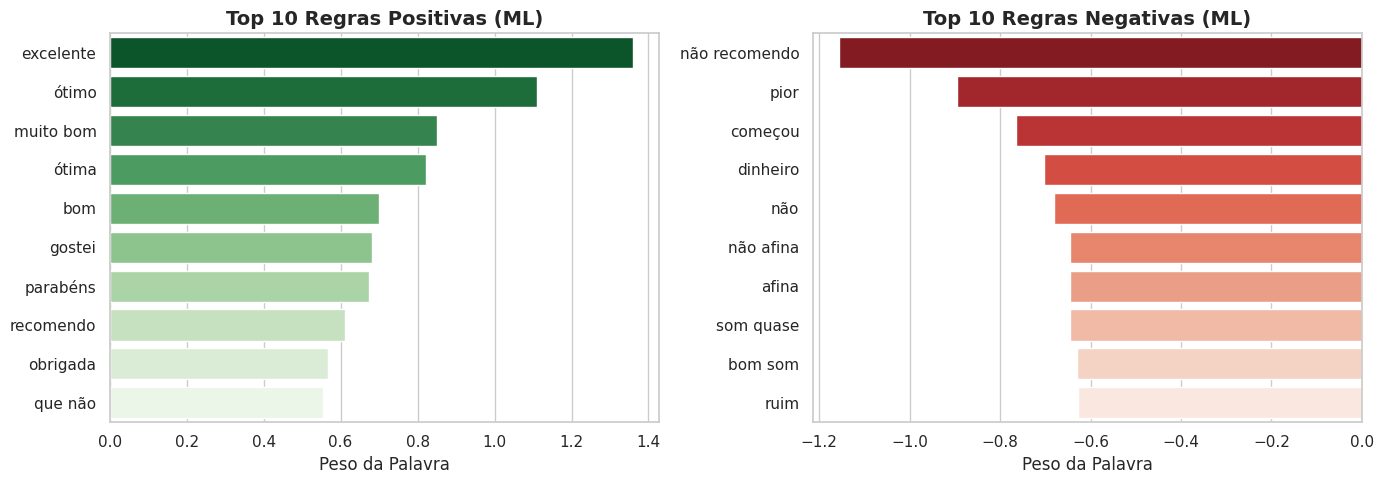

/tmp/ipykernel_2417/1832452279.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=modelos, y=valores, palette=['#e74c3c', '#2ecc71'])


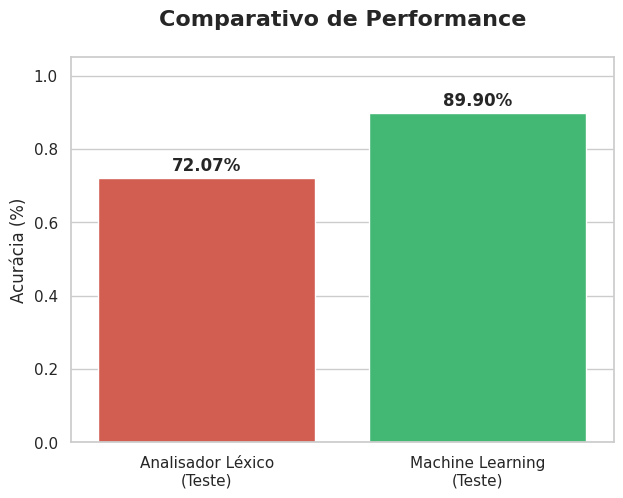

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Configuração visual padrão para deixar os gráficos mais bonitos
sns.set_theme(style="whitegrid")

# ==========================================
# GRÁFICO 1: MAPA DE CALOR DA MATRIZ DE CONFUSÃO
# ==========================================
plt.figure(figsize=(7, 5))
cm = confusion_matrix(df_teste['sentimento_real'], df_teste['predicao_ml'])

# Criando o Heatmap (Mapa de Calor)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusão (Machine Learning)\n', fontsize=16, fontweight='bold')
plt.ylabel('Sentimento REAL', fontsize=12, fontweight='bold')
plt.xlabel('\nPredição do MODELO', fontsize=12, fontweight='bold')
plt.show() # Exibe o primeiro gráfico


# ==========================================
# GRÁFICO 2: TOP PALAVRAS (MACHINE LEARNING)
# ==========================================
# Resgatando as palavras e pesos que já calculamos antes
palavras = vectorizer.get_feature_names_out()
pesos = modelo_ml.coef_[0]
df_pesos = pd.DataFrame({'Palavra': palavras, 'Peso': pesos})

top_pos = df_pesos.sort_values(by='Peso', ascending=False).head(10)
top_neg = df_pesos.sort_values(by='Peso', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Barras Verdes (Positivas)
sns.barplot(x='Peso', y='Palavra', data=top_pos, ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Regras Positivas (ML)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Peso da Palavra', fontsize=12)
axes[0].set_ylabel('')

# Gráfico de Barras Vermelhas (Negativas)
sns.barplot(x='Peso', y='Palavra', data=top_neg, ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Regras Negativas (ML)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Peso da Palavra', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show() # Exibe o segundo gráfico


# ==========================================
# GRÁFICO 3: COMPARATIVO DE ACURÁCIA
# ==========================================
plt.figure(figsize=(7, 5))
# Puxando as variáveis de acurácia que você já calculou
modelos = ['Analisador Léxico\n(Teste)', 'Machine Learning\n(Teste)']
valores = [acuracia_lexical_teste, acuracia_ml]

ax = sns.barplot(x=modelos, y=valores, palette=['#e74c3c', '#2ecc71'])
plt.title('Comparativo de Performance\n', fontsize=16, fontweight='bold')
plt.ylabel('Acurácia (%)', fontsize=12)
plt.ylim(0, 1.05) # Define o eixo Y de 0 a 100%

# Adicionando a porcentagem em cima de cada barra
for i, v in enumerate(valores):
    ax.text(i, v + 0.02, f"{v:.2%}", ha='center', fontsize=12, fontweight='bold')

plt.show() # Exibe o terceiro gráfico